In [1]:

from LLMHeuristicScheduler.base import LLMHeuristicScheduler
from sampo_api import contractor
from scripts.metrics import StatsCollector, StatsHandler


from sampo.base import SAMPO
from sampo.scheduler.genetic import GeneticScheduler
from sampo.schemas.graph import WorkGraph



import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict


Can not find native module; switching to default


# Genetic Algrotihm basic SAMPO  vs Genetic Algorithm with LLMs generated init population

Цель исследования:    
    - Проверить сходимость за сколько был достигнут GAP = 0,   
    Гипотеза: Iter_LLM <  Iter_GA    
    - Оптимальность  
    Гипотеза: makespan_LLM < makespan_GA


In [2]:
def init_experiment(GA_params, model_names, imprortance):
    solvers_dict = {}
    solvers_dict['genetic'] = GeneticScheduler(**GA_params)
    for model_name in model_names:
        model = LLMHeuristicScheduler(model_name, **GA_params, 
                                      imprortance=imprortance)
        solvers_dict[model_name] = model
    return solvers_dict

def experiment_df(experiment_logs):
    res = []
    for name, runs in experiment_logs.items():
        for i, run in enumerate(runs, start=1):
            df = pd.DataFrame({'Makespan' : run, 'Time' : range(1, len(run) + 1), 'run' : i, 'Algorithm' : name})
            res.append(df)
    df_res = pd.concat(res)
    return df_res

def run_experiment(solvers_dict, wg, contractors, N_runs):
    sc = StatsCollector()
    stats_handler = StatsHandler(sc)
    SAMPO.logger.addHandler(stats_handler)
    experiment_logs = defaultdict(list)
    for i in range(N_runs):
        for solver, model in solvers_dict.items():
            model.schedule(wg, contractors)
            experiment_logs[solver].append(sc.items)
            sc.clear()
    return experiment_logs



GA  = {
    'number_of_generation' : 3,
    'size_of_population' : 60,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 


#wg , contractors  = WorkGraph.loadf('wgs/100', '100_0'), contractor(N=5)


wg , contractors  = WorkGraph.loadf('wgs/small_synth', 'wg_5'), contractor(N=5)
solvers_dict = init_experiment(GA, ['claude_haiku_4.5', ], 9)
experiment_logs = run_experiment(solvers_dict, wg, contractors, 3)


[SAMPO] [INFO] Toolbox initialization & first population took 7.360696792602539 ms


Genetic optimizing took 7.210016250610352 ms


[SAMPO] [INFO] First population evaluation took 410.53175926208496 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(65.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(65.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(65.0,) --
[SAMPO] [INFO] Final fitness: (65.0,)
[SAMPO] [INFO] Generations processing took 1139.6710872650146 ms
[SAMPO] [INFO] Full genetic processing took 2515.8467292785645 ms
[SAMPO] [INFO] Evaluation time: 1475.2368927001953
[SAMPO] [INFO] Toolbox initialization & first population took 11.15274429321289 ms


+1 solve Latest Start Time Priority Rule (LST) 127
+1 solve Shortest Processing Time Priority Rule (SPT) 32
+1 solve Greatest Resource Demand Priority Rule (GRD) 74
+1 solve Most Successors Priority Rule (MS2) 78
+1 solve Minimum Slack Priority Rule (MS1) 117
+1 solve Latest Finish Time Priority Rule (LFT) 92
Genetic optimizing took 10.936737060546875 ms


[SAMPO] [INFO] First population evaluation took 349.08485412597656 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(64.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(64.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(64.0,) --
[SAMPO] [INFO] Final fitness: (64.0,)
[SAMPO] [INFO] Generations processing took 1156.2488079071045 ms
[SAMPO] [INFO] Full genetic processing took 2306.9047927856445 ms
[SAMPO] [INFO] Evaluation time: 1431.8478107452393
[SAMPO] [INFO] Toolbox initialization & first population took 6.952762603759766 ms


...

[SAMPO] [INFO] First population evaluation took 368.73793601989746 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(67.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(66.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(66.0,) --
[SAMPO] [INFO] Final fitness: (66.0,)
[SAMPO] [INFO] Generations processing took 1275.3398418426514 ms
[SAMPO] [INFO] Full genetic processing took 2459.845781326294 ms
[SAMPO] [INFO] Evaluation time: 1566.38503074646
[SAMPO] [INFO] Toolbox initialization & first population took 7.126092910766602 ms


Genetic optimizing took 6.654024124145508 ms


[SAMPO] [INFO] First population evaluation took 363.5866641998291 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(72.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(72.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(72.0,) --
[SAMPO] [INFO] Final fitness: (72.0,)
[SAMPO] [INFO] Generations processing took 1161.167860031128 ms
[SAMPO] [INFO] Full genetic processing took 2465.620994567871 ms
[SAMPO] [INFO] Evaluation time: 1414.7024154663086
[SAMPO] [INFO] Toolbox initialization & first population took 38.79380226135254 ms


+1 solve Latest Start Time Priority Rule (LST) 127
+1 solve Shortest Processing Time Priority Rule (SPT) 32
+1 solve Greatest Resource Demand Priority Rule (GRD) 74
+1 solve Most Successors Priority Rule (MS2) 78
+1 solve Minimum Slack Priority Rule (MS1) 117
+1 solve Latest Finish Time Priority Rule (LFT) 92
Genetic optimizing took 38.56086730957031 ms


[SAMPO] [INFO] First population evaluation took 365.8943176269531 ms
[SAMPO] [INFO] -- Generation 1, population=60, best fitness=(47.0,) --
[SAMPO] [INFO] -- Generation 2, population=60, best fitness=(47.0,) --
[SAMPO] [INFO] -- Generation 3, population=60, best fitness=(47.0,) --
[SAMPO] [INFO] Final fitness: (47.0,)
[SAMPO] [INFO] Generations processing took 1228.9559841156006 ms
[SAMPO] [INFO] Full genetic processing took 2434.2057704925537 ms
[SAMPO] [INFO] Evaluation time: 1484.241247177124


(0.0, 75.0)

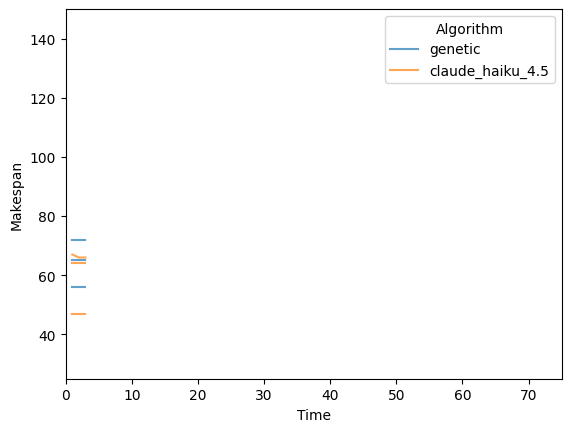

In [3]:
sns.lineplot(experiment_df(experiment_logs),
              x='Time', y='Makespan', hue='Algorithm', 
              units='run', estimator=None, alpha=0.7)

plt.ylim((25, 150))
plt.xlim((0, 75))

# Проверка гипотезы о весах в ГА

In [ ]:
def tail_share(weights, tail_indices, p_init=1/3):
    W = sum(weights)
    W_tail = sum(weights[tail_indices:])
    return p_init * W_tail / W  # доля в общей популяции


print('Deepseek Chat')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [1] * 9, tail_indices=7) / 0.33 )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [5] * 9, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [12] * 9, tail_indices=7), tail_share([2, 2, 2, 2, 1, 1, 1] + [10] * 9, tail_indices=7) / 0.33)


print('Reasoner')
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [0.5] * 5, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [2] * 5, tail_indices=7) / 0.33 )
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [6] * 5, tail_indices=7) / 0.33)
print( tail_share([2, 2, 2, 2, 1, 1, 1] + [12] * 5, tail_indices=7) )


In [ ]:
from sampo.schemas.graph import WorkGraph

def init_experiment(GA_params, model_names, imprt):
    solvers_dict = {}
    solvers_dict['genetic'] = GeneticScheduler(**GA_params)
    for model_name in model_names:
        model = LLMHeuristicScheduler(model_name, **GA_params, imprt=imprt)
        solvers_dict[model_name] = model
    return solvers_dict

def experiment_df(experiment_logs):
    res = []
    for name, runs in experiment_logs.items():
        if name == 'weight_param':
            continue
        for i, run in enumerate(runs, start=1):
            df = pd.DataFrame({'Makespan' : run, 'Time' : range(1, len(run) + 1), 'run' : i, 'Algorithm' : name})
            res.append(df)
    df_res = pd.concat(res)
    df_res['weight_param'] = experiment_logs['weight_param'] 
    return df_res

def run_experiments(GA, wg, weights, contractors, N_runs):
    sc = StatsCollector()
    stats_handler = StatsHandler(sc)
    SAMPO.logger.addHandler(stats_handler)
    res_dfs = []
    for weight in weights:
        experiment_logs = defaultdict(list)
        solvers_dict = init_experiment(GA, ['deepseek_chat', 'deepseek_reasoner'], imprt=weight)
        for _ in range(N_runs):
            for solver, model in solvers_dict.items():
                if weight >= weights[0] and solver == 'genetic':
                # Skip other experiments
                    continue
                model.schedule(wg, contractors)
                experiment_logs[solver].append(sc.items)
                experiment_logs['weight_param'] = weight
                sc.clear()
            res_dfs.append(experiment_df(experiment_logs))
    
    return res_dfs


GA  = {
    'number_of_generation' : 150,
    'size_of_population' : 50,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 


weights = (8, 9, 10)


wg , contractors  = WorkGraph.loadf('wgs/small_synth', 'wg_9'), contractor(N=5)
dfs = run_experiments(GA, wg, contractors, 5)


In [ ]:
data = pd.concat(dfs)
data.to_csv('weight_experiment2_df.csv', index=False)

#data.to_csv('weight_experiment2_weights_df.csv', index=False)


# Meta

# GA  = {
#     'number_of_generation' : 150,
#     'size_of_population' : 50,
#     'mutate_order' : 0.05,
#     'mutate_resources': 0.05,
#     'mutate_zones': 0.05} 


#df_experiment.to_csv('weight_experiment_df.csv', index=False)


# Meta

# GA  = {
#     'number_of_generation' : 100,
#     'size_of_population' : 50,
#     'mutate_order' : 0.05,
#     'mutate_resources': 0.05,
#     'mutate_zones': 0.05} 



In [ ]:
# from sampo.schemas.graph import WorkGraph
# import os
# from sampo_api import contractor

# maxx, minn = -float('inf'), float('inf')
# for f in os.listdir('wgs/small_synth'):
#         wg , contractors = WorkGraph.loadf('wgs/small_synth', f[:-5]), contractor(N=5)
#         N = len(wg.nodes) 
#         print( f, N)
#         maxx = max(maxx, N)
#         minn = min(minn, N)

# print(maxx, minn)

# Experiment with structure in GA
    - `Classic` GA vs `High Weight` in init_popul vs `Only model generated` init_popul

In [ ]:
from LLMHeuristicScheduler.base import LLMHeuristicScheduler
from sampo_api import contractor
from sampo.schemas.graph import WorkGraph

wg , contractors  = WorkGraph.loadf('wgs/100', '100_0'), contractor(N=10)


def experiment_df(experiment_logs):
    res = []
    for name, runs in experiment_logs.items():
        for i, run in enumerate(runs, start=1):
            df = pd.DataFrame({'Makespan' : run, 'Time' : range(1, len(run) + 1), 
                               'run' : i, 'Algorithm' : name})
            res.append(df)
    df_res = pd.concat(res)
    return df_res



def init_experiment(GA_params, 
                    model_name, 
                    structures = (None, 'onlyGeneratedHeurisitcs'), 
                    imprt = 10):
    solvers_dict = {}
    solvers_dict['genetic'] = GeneticScheduler(**GA_params)
    for structure in structures:
        model = LLMHeuristicScheduler(model_name, 
                                      **GA_params, 
                                      type_init_pop_structure=structure, 
                                      imprortance=imprt)
        if structure is None:
            structure = 'highWeights'
        solvers_dict[model_name + '_' + structure] = model
    return solvers_dict

def run_experiments(GA, wg, contractors, model_name, N_runs):
    sc = StatsCollector()
    stats_handler = StatsHandler(sc)
    SAMPO.logger.addHandler(stats_handler)
    res_dfs = []
    experiment_logs = defaultdict(list)
    solvers_dict = init_experiment(GA, model_name)
    for _ in range(N_runs):
        for solver, model in solvers_dict.items():
            model.schedule(wg, contractors)
            experiment_logs[solver].append(sc.items)
            sc.clear()
            res_dfs.append(experiment_df(experiment_logs))
    return res_dfs


GA  = {
    'number_of_generation' : 100,
    'size_of_population' : 50,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 

dfs = run_experiments(GA, wg, contractors, 'deepseek_reasoner', 4)

In [ ]:
pd.concat(dfs).groupby('Algorithm').Makespan.min()

In [ ]:
pd.concat(dfs).to_csv('structure_experiment_DRChat.csv', index=False)

In [ ]:
str(None)

In [ ]:
# from sampo.schemas.graph import WorkGraph
# WorkGraph.loadf('wgs/100', '100_0')

In [ ]:
GA  = {
    'number_of_generation' : 150,
    'size_of_population' : 50,
    'mutate_order' : 0.05,
    'mutate_resources': 0.05,
    'mutate_zones': 0.05} 
scheduler = LLMHeuristicScheduler('deepseek_reasoner', 
                                  **GA,  
                                 type_init_pop_structure='onlyGeneratedHeurisitcs')
scheduler.schedule(wg, contractors)
